# 0043SAM — grain milling

RAMP calibration notebook. To study another client, edit the two
lines of the next cell and run everything again.

In [1]:
CLIENT = "0043SAM"
PUE_TYPE = "grain_milling"

# Study period to calibrate on (the meter file may hold more days than the
# appliance's service period; set both to None to use the whole file).
PERIOD_START = "2025-02-04"
PERIOD_END = "2025-12-14"

# Appliance rated power in W, used as a physical ceiling in the
# calibration (set to None to disable the cap).
RATED_POWER_W = 7500


In [2]:
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

REPO = Path.cwd().resolve().parents[1]      # notebooks/<type>/ -> repository root
sys.path.append(str(REPO / "src"))
import run

RESULTS = REPO / "resultats" / PUE_TYPE / CLIENT
FIGURES = RESULTS / "figures"


def show(*patterns):
    """Display every figure matching the given file patterns, in order."""
    for pattern in patterns:
        for path in sorted(FIGURES.glob(pattern)):
            display(Image(filename=str(path), width=900))

## Run the full chain

The next cell runs the seven steps (preprocessing, clustering,
calibration, figures, summary) on this client. Progress appears
below as it happens; the whole chain takes about 10 to 15 minutes.

In [3]:
run.run(PUE_TYPE, CLIENT, period_start=PERIOD_START,
        period_end=PERIOD_END, rated_power_W=RATED_POWER_W)

[step1] 0043SAM: 104 active days kept, 176 inactive, 34 rejected, 73 outages -> resultats/grain_milling/0043SAM


[step2] 0043SAM: 1 clusters, 1 noise days, 4 seasonal targets


[step3] 0043SAM: 12 clustering figures -> resultats/grain_milling/0043SAM/figures


[step4] October: 3 windows [07:30-12:00, 13:00-17:30, 18:15-19:00]  start std 10 min


[step5] October: p1 5854 W  p2 0.0 W  t_on 14 min  [07h-12h d=0.43, 13h-17h d=0.25, 18h-19h d=0.50]


[step6] October: cap 0.15  zero 4/6 NRMSE 0.128  act 4/6 NRMSE 0.126


[step7] October: classic  3 regions  L 22 min  tfrv 0.67  amp 1.01  rescue 8


[step8] October: fit 4/6  NRMSE 0.123+/-0.001  holdout 0.123 (floor 0.000)


[step9] 0043SAM: calibration figures -> resultats/grain_milling/0043SAM/figures


[step10] grain_milling: 16 client-seasons, criteria passed 60/96


## Client identity card

In [4]:
clean = pd.read_csv(RESULTS / "timeseries_clean.csv", index_col=0,
                    parse_dates=True)
daily = pd.read_csv(RESULTS / "daily_matrix_W.csv", index_col=0,
                    parse_dates=True)
kept = pd.read_csv(RESULTS / "clustered_features.csv", index_col=0)
card = pd.Series({
    "Client": CLIENT,
    "PUE type": PUE_TYPE.replace("_", " "),
    "Site": "Samionta" if CLIENT.endswith("SAM") else "Gbowele",
    "Rated power (W)": RATED_POWER_W if RATED_POWER_W else "-",
    "Study period": f"{PERIOD_START} to {PERIOD_END}",
    "Raw days with data": int(pd.Series(clean.index.normalize()).nunique()),
    "Complete days (96 slots)": len(daily),
    "Days kept after filtering": len(kept),
})
card.to_frame("value")

,value
Client,0043SAM
PUE type,grain milling
Site,Samionta
Rated power (W),7500
Study period,2025-02-04 to 2025-12-14
Raw days with data,314
Complete days (96 slots),104
Days kept after filtering,104


## Measured seasonal profiles and day-by-hour heatmap and activity timeline

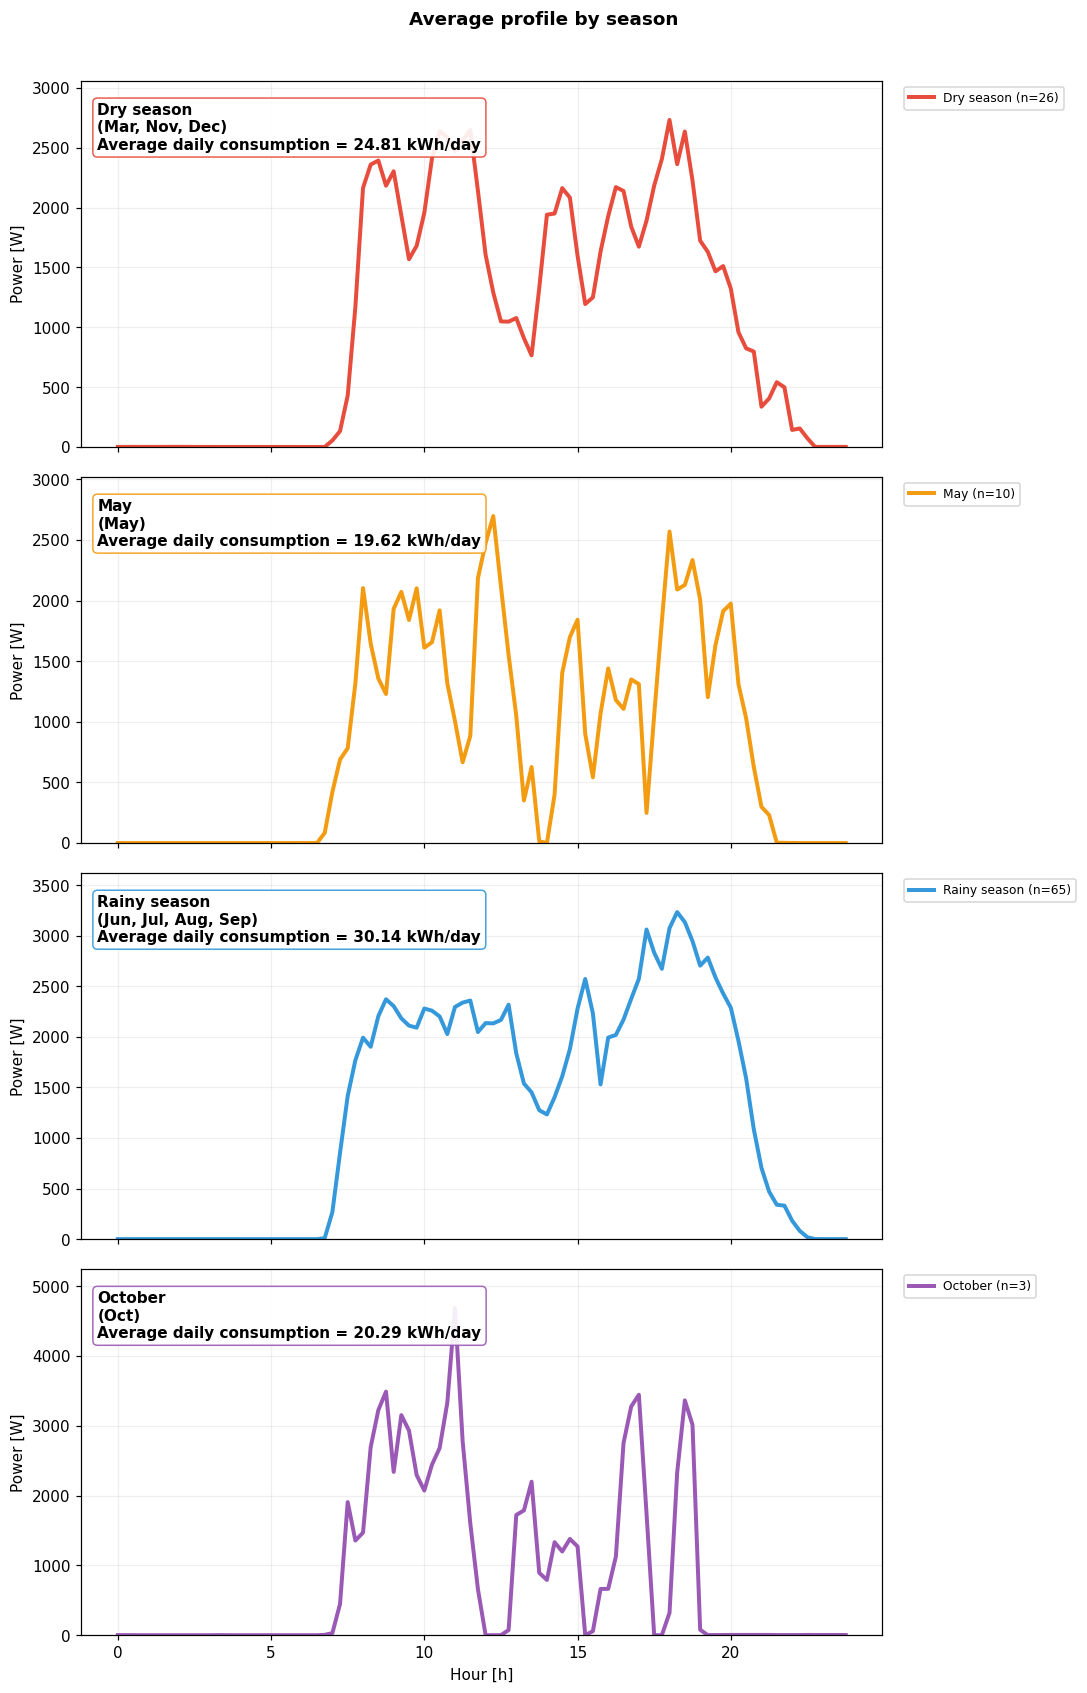

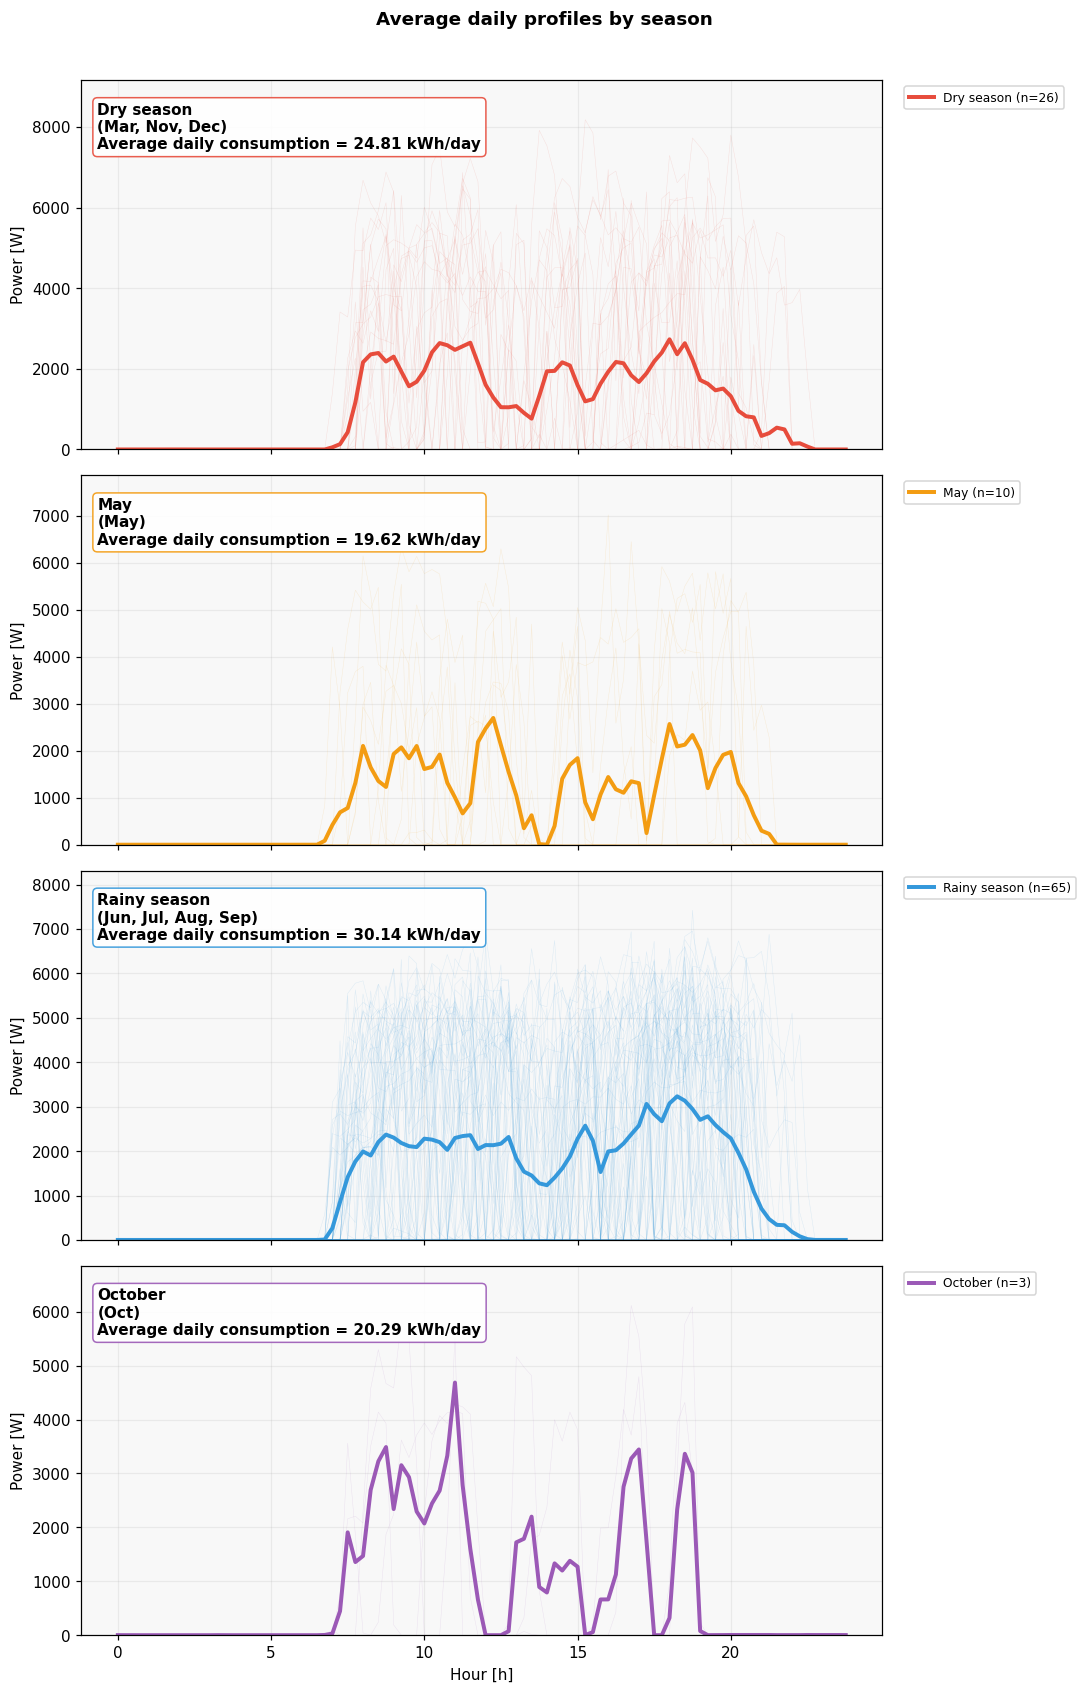

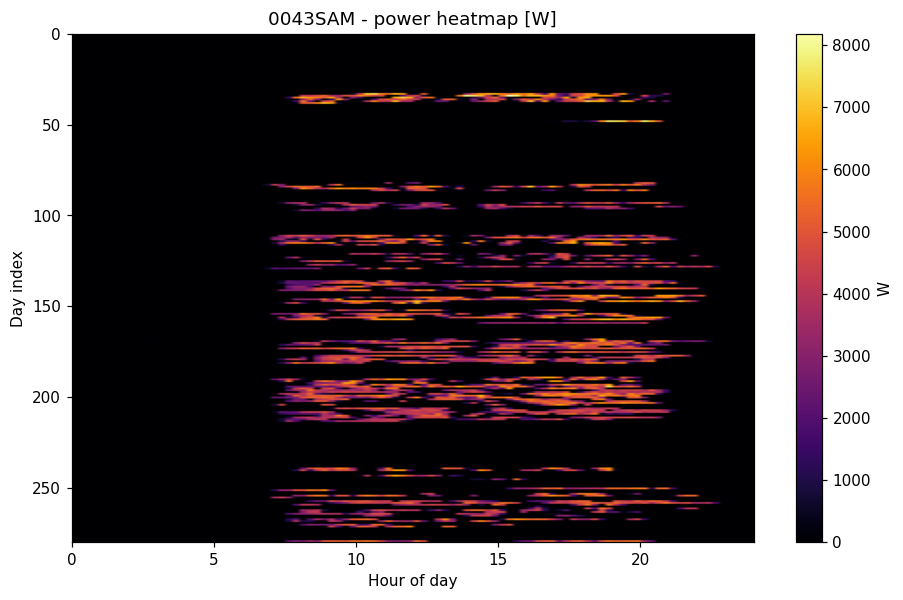

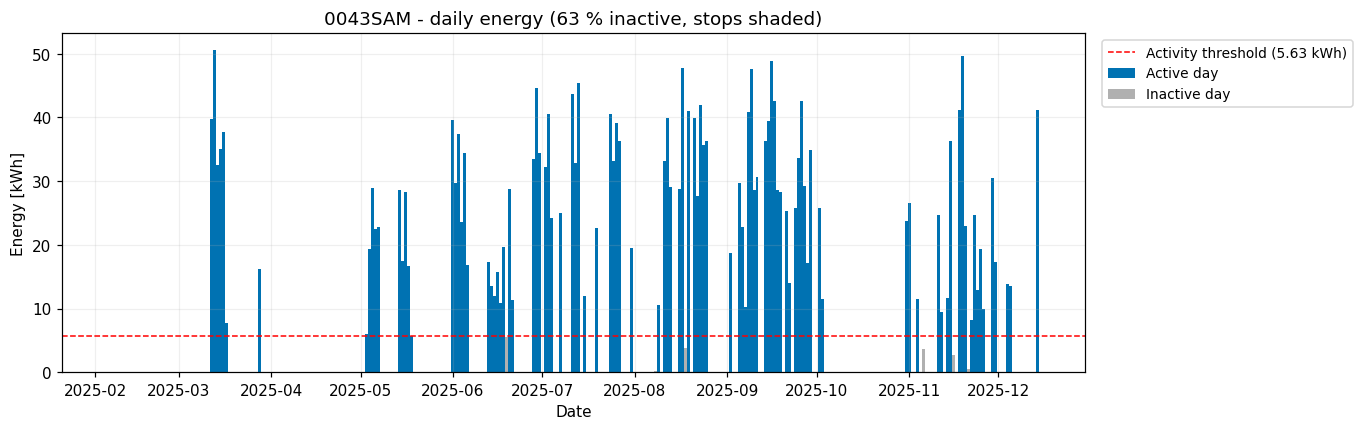

In [5]:
show("07_season_profiles.png", "07b_season_profiles_stacked.png",
     "0*_heatmap.png", "03_activity_timeline.png")

## Clustering

k-distance heuristic, cluster sizes, cluster profiles, feature
scatters and the season/cluster distribution.

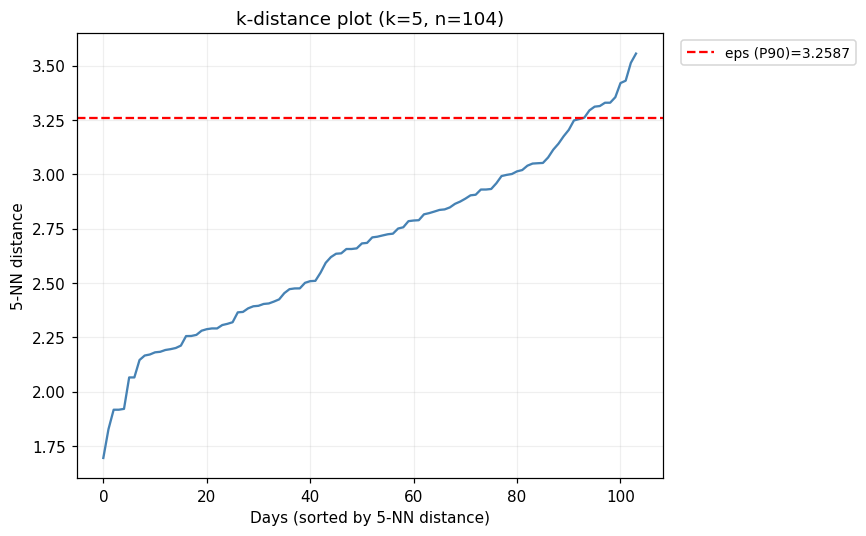

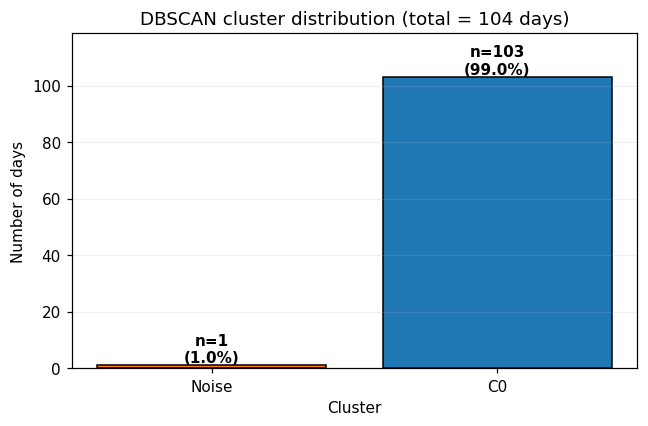

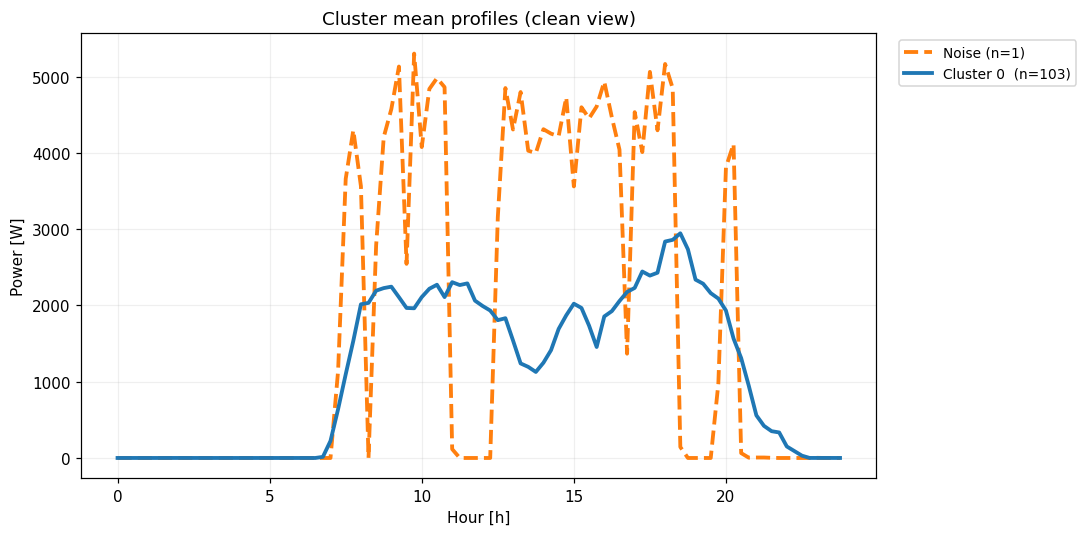

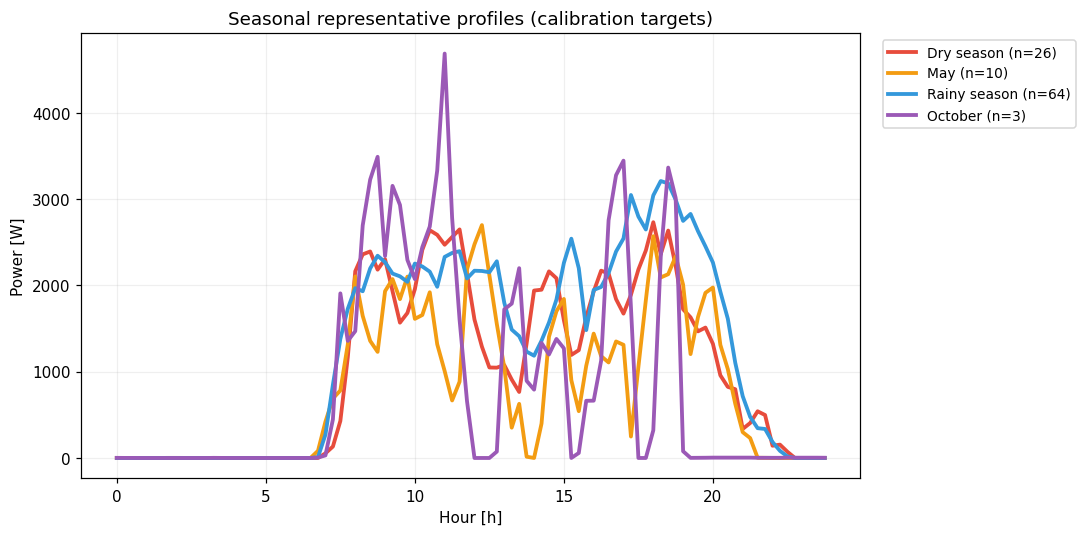

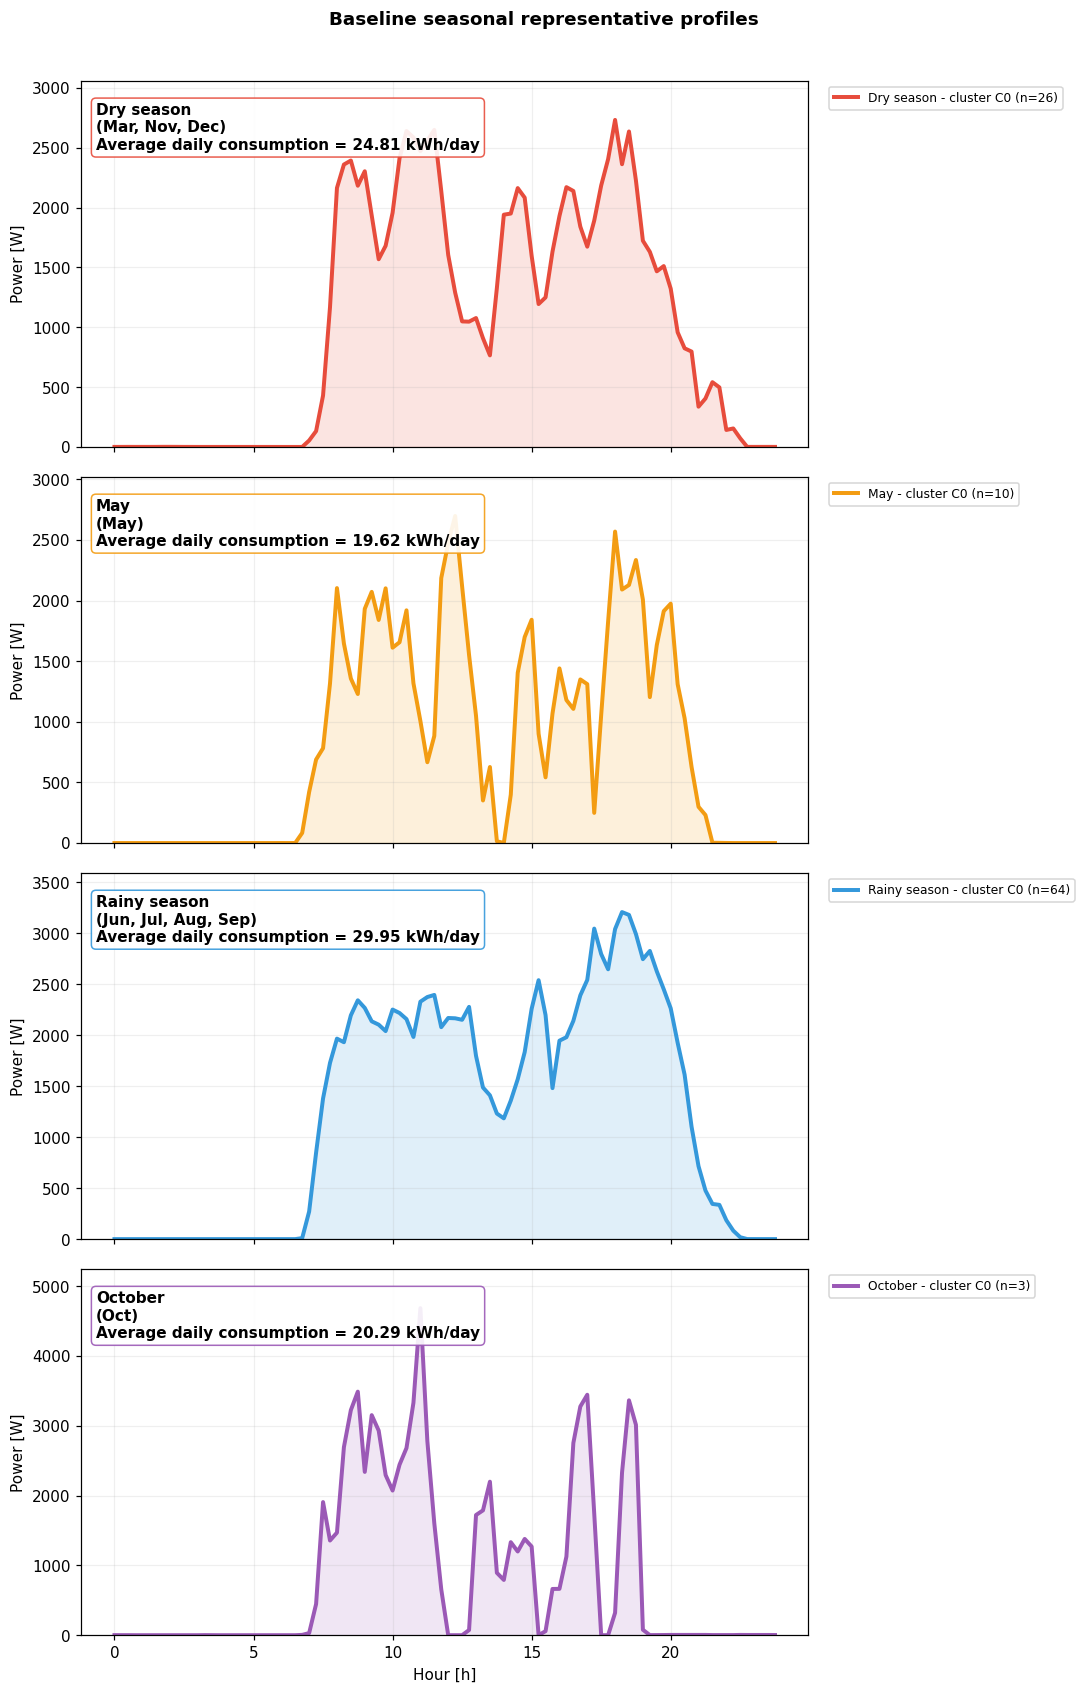

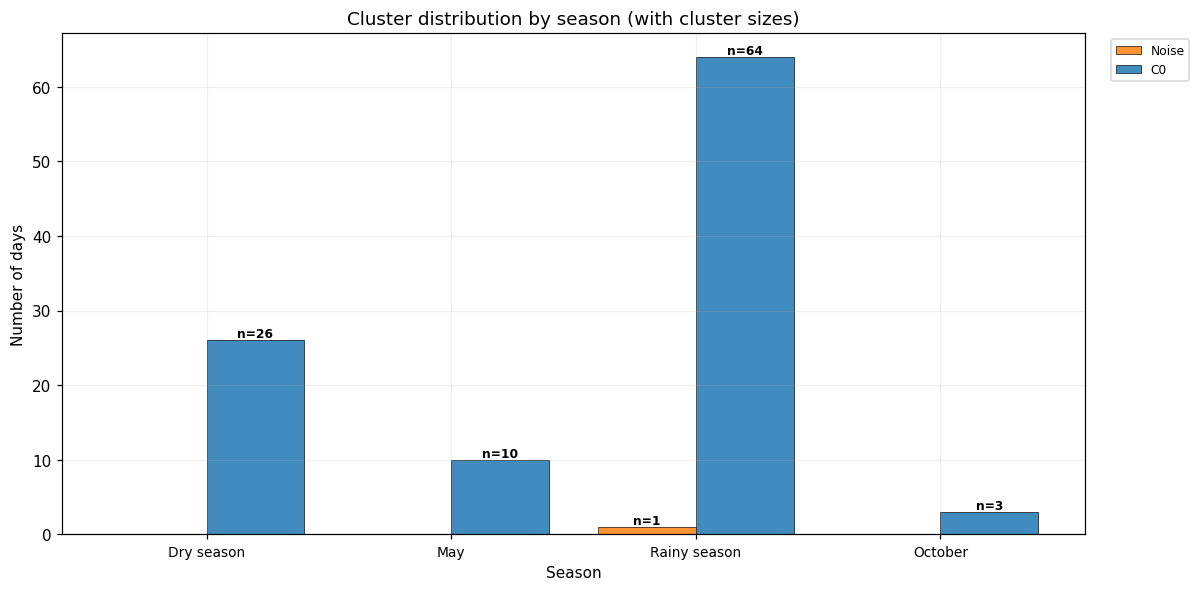

In [6]:
show("08_k_distance_plot.png", "0*_cluster_histogram.png",
     "*_cluster_profiles*.png", "*repr*.png",
     "12_scatter_E_Ppeak.png", "13_scatter_E_LF.png",
     "14_scatter_Ppeak_peakH.png", "15_season_cluster_bar.png")

## Dry season

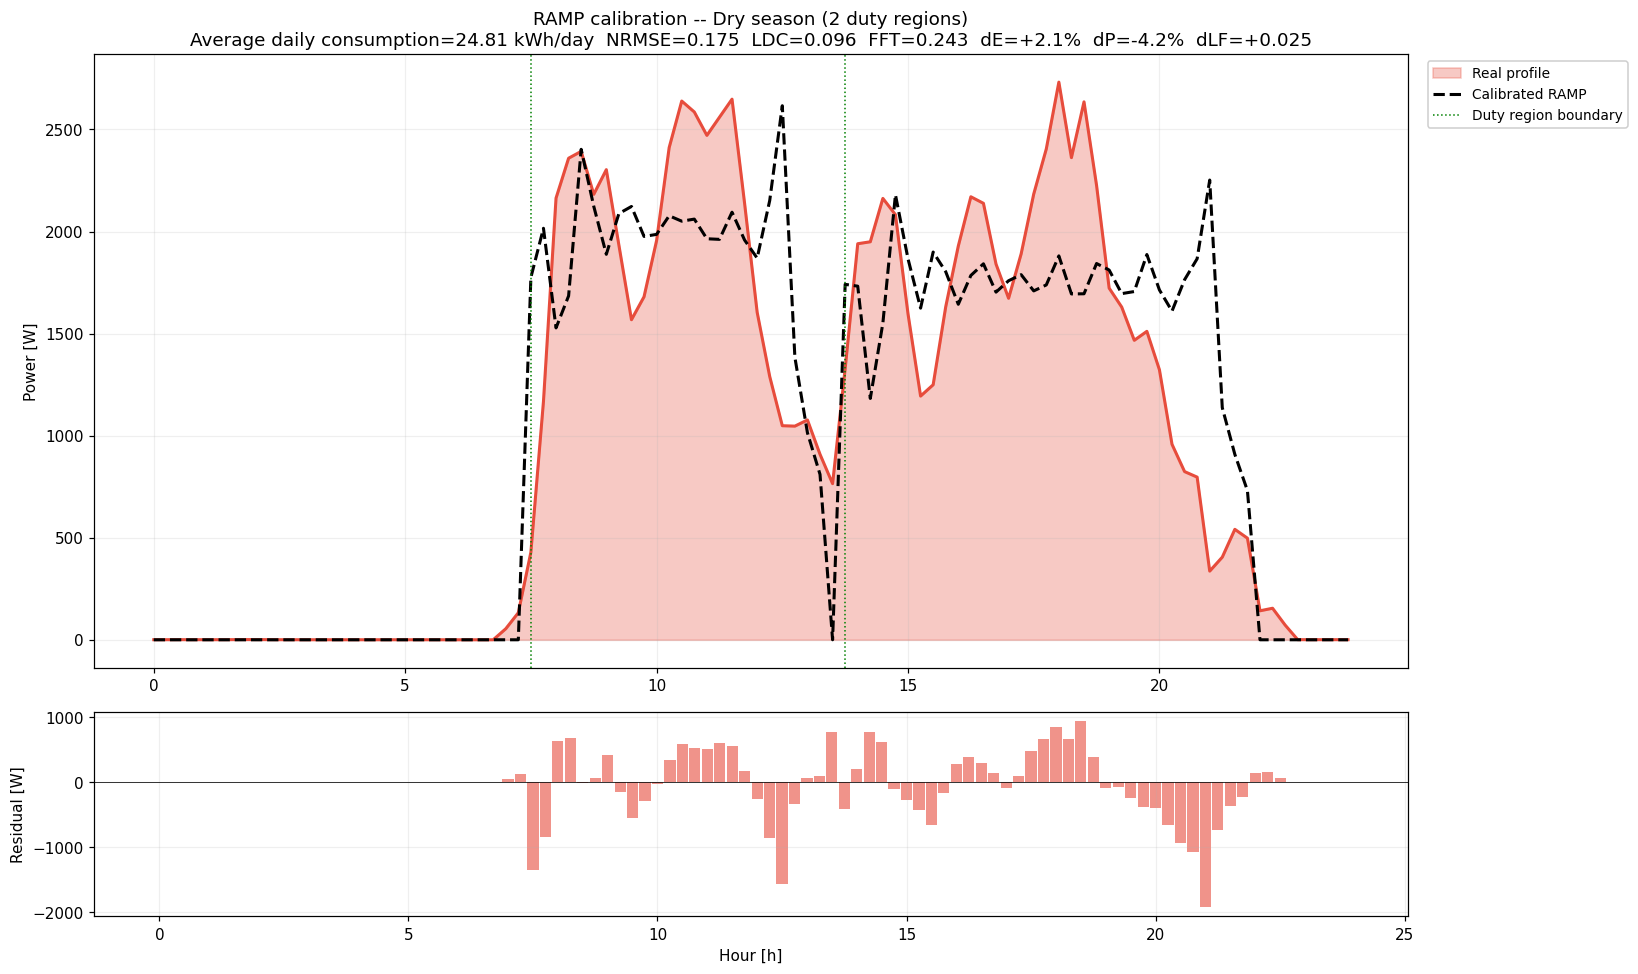

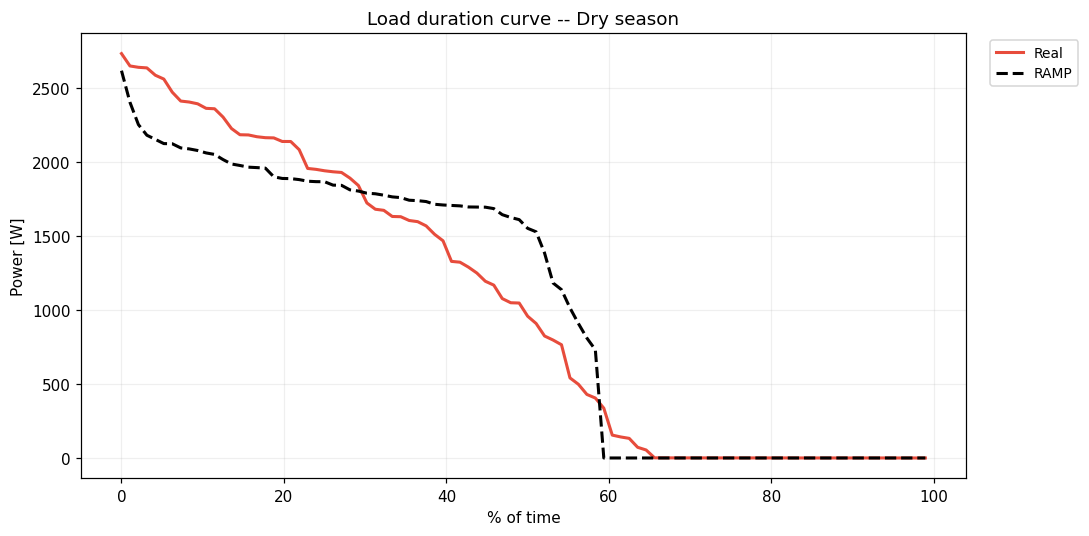

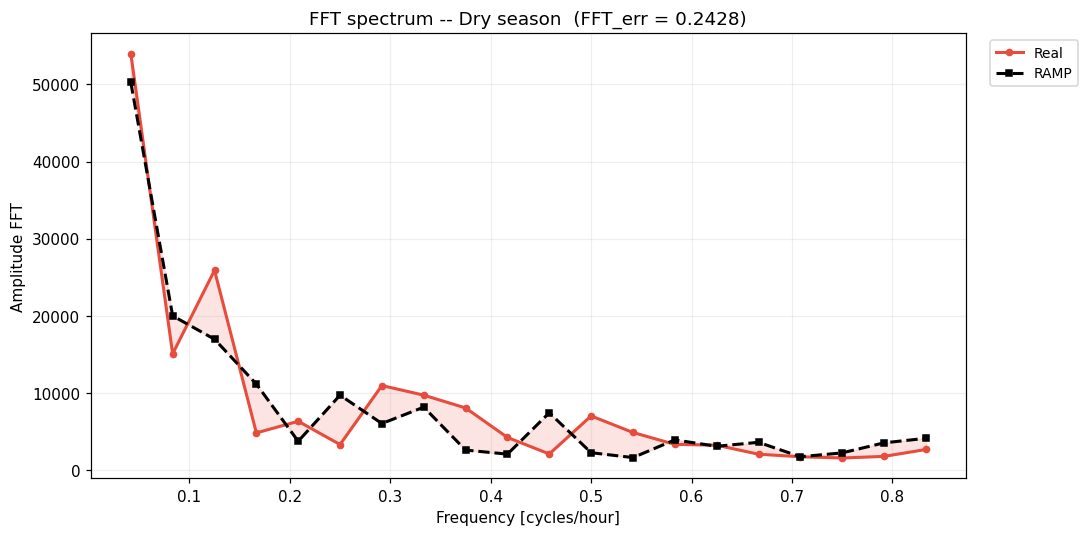

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
0,Dry season,4,0.175,0.096,0.243,2.143,-4.231,0.025


In [7]:
season = "Dry season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Dry_season.png", f"41_ldc_Dry_season.png", f"42_fft_Dry_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## May

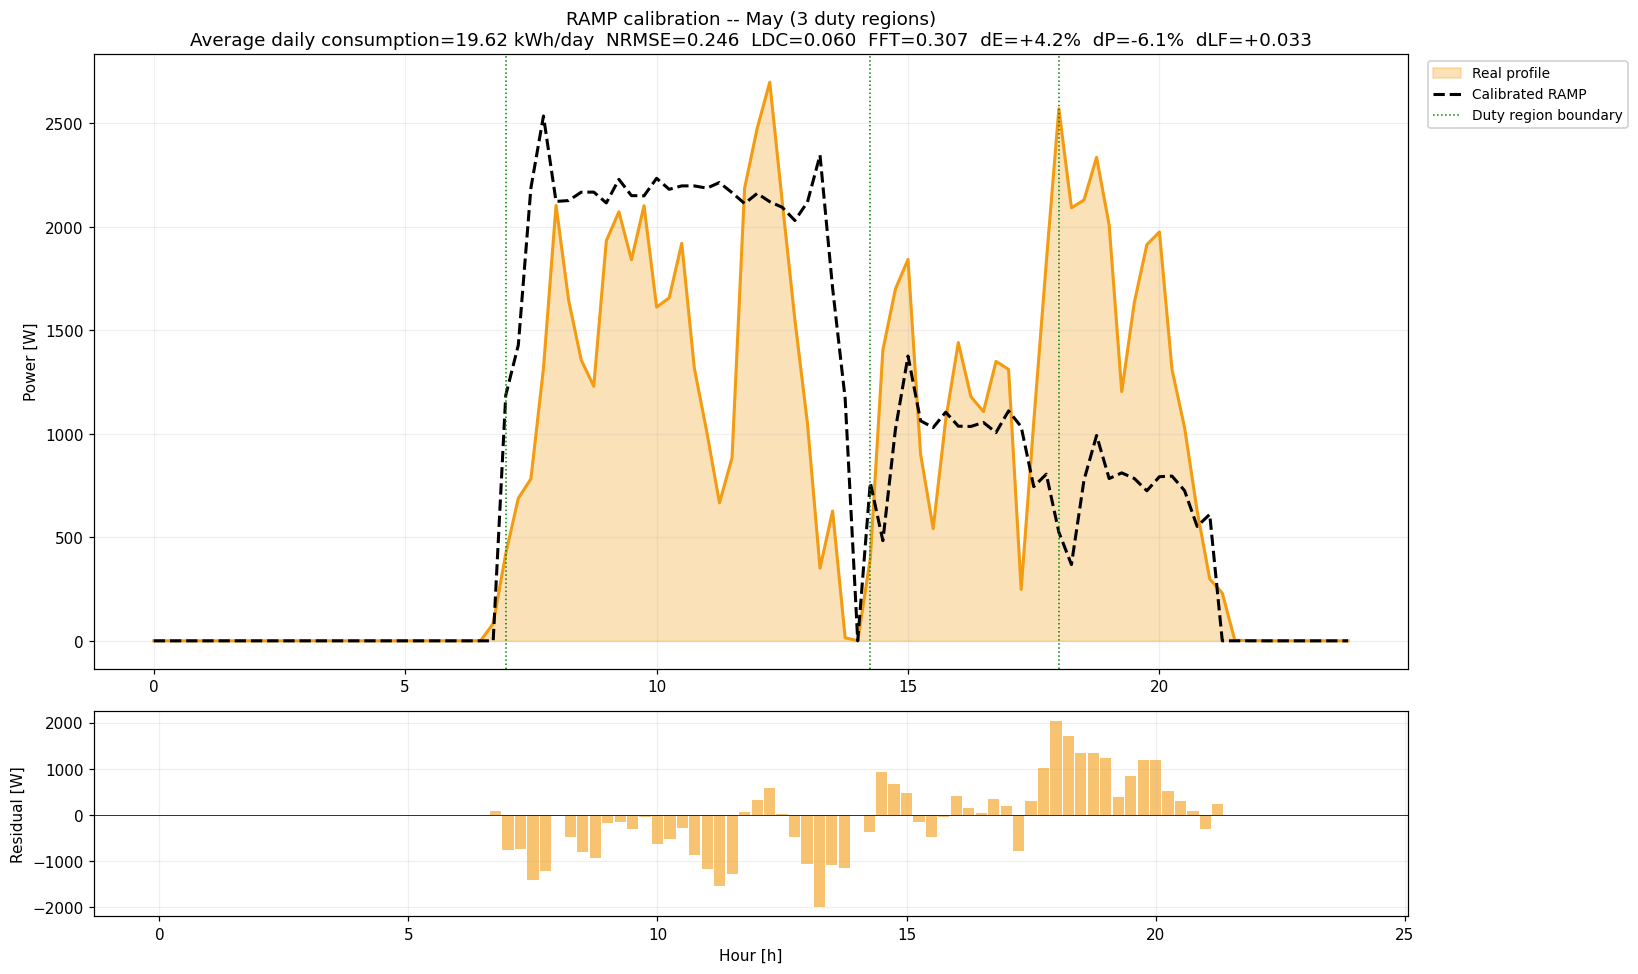

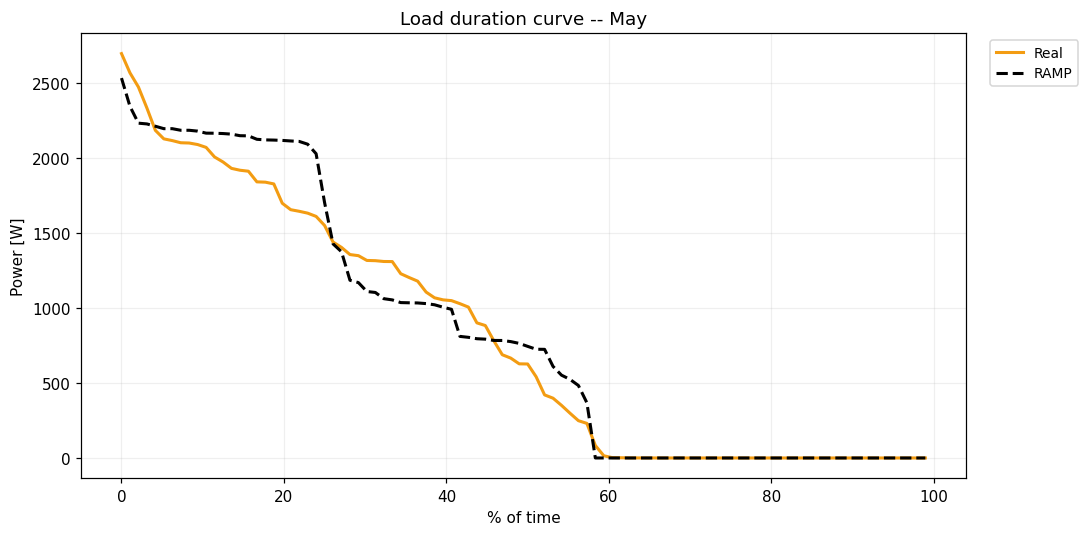

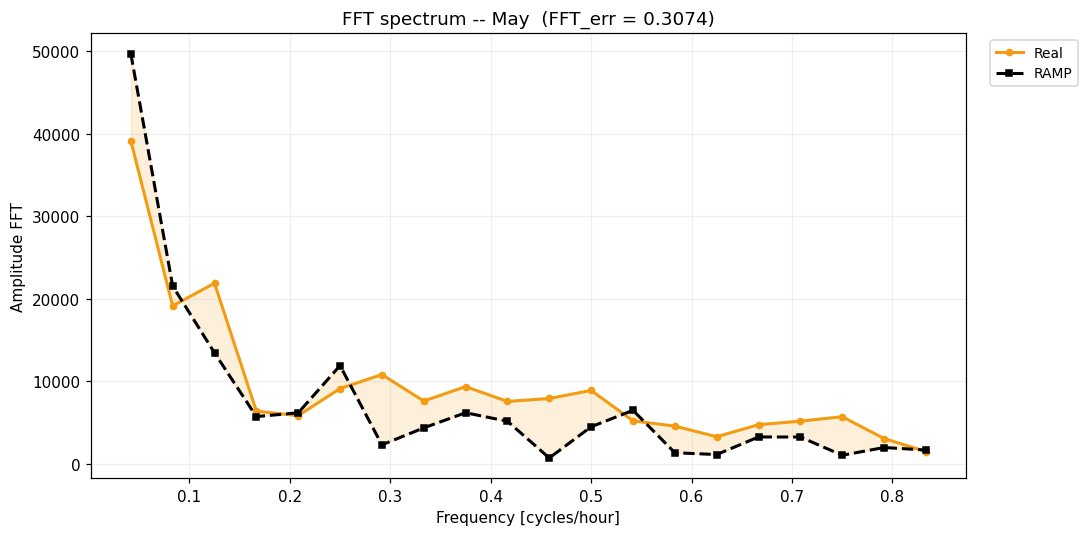

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
1,May,4,0.246,0.06,0.307,4.152,-6.059,0.033


In [8]:
season = "May"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_May.png", f"41_ldc_May.png", f"42_fft_May.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Rainy season

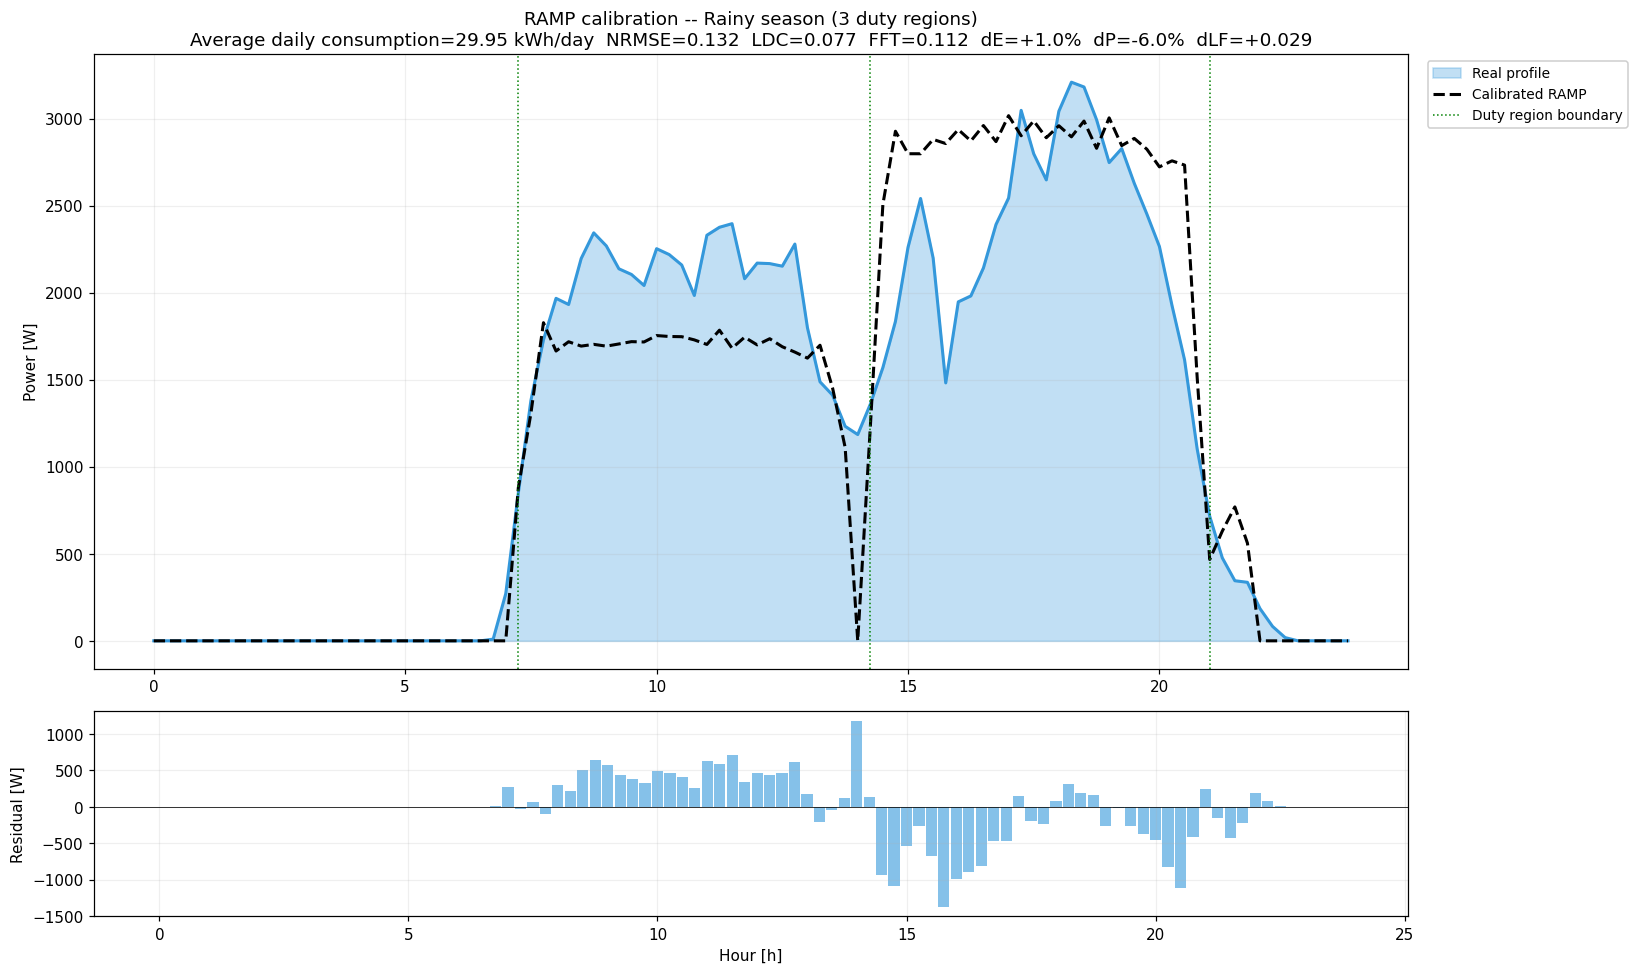

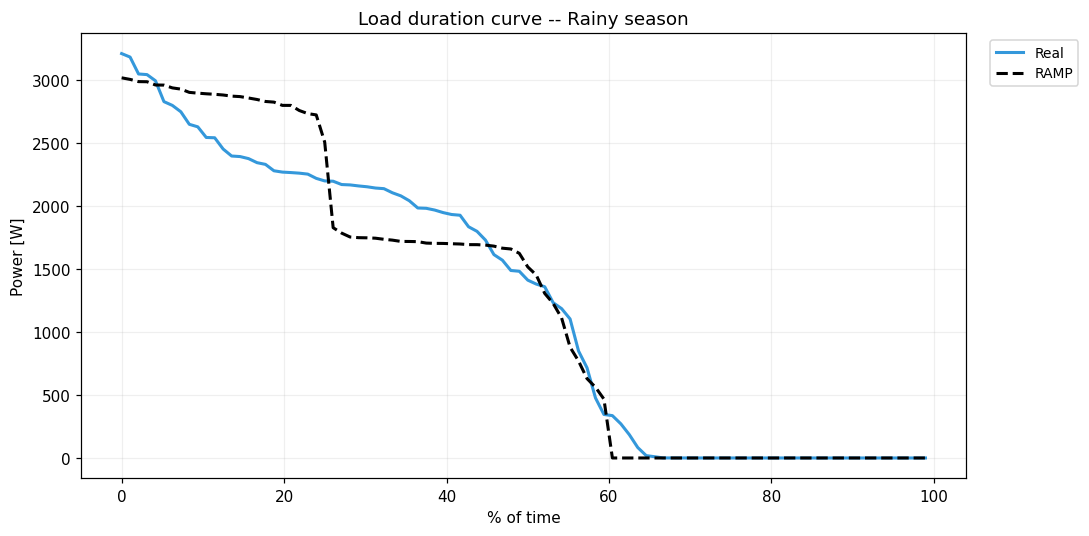

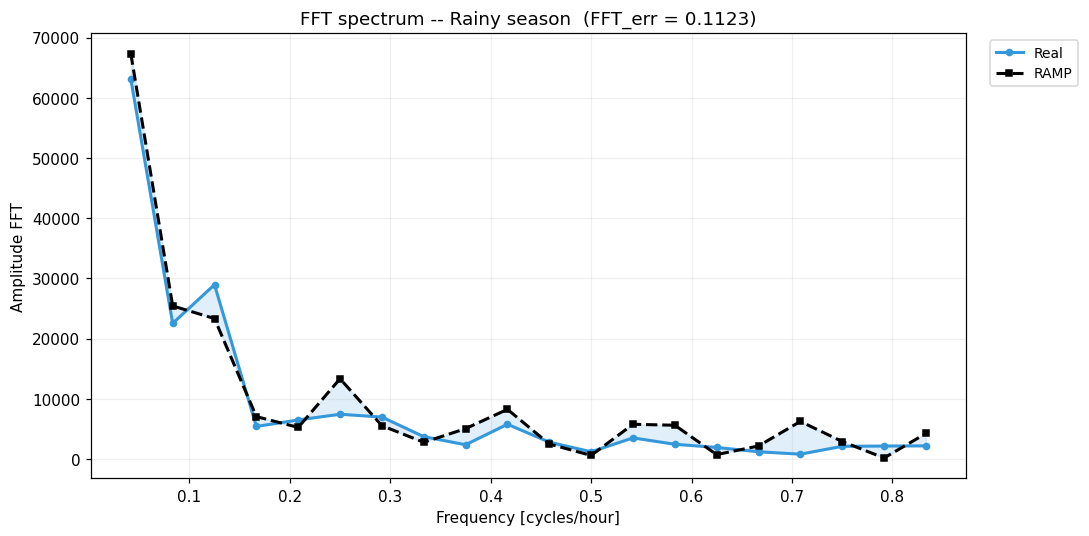

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
2,Rainy season,4,0.132,0.077,0.112,0.992,-5.993,0.029


In [9]:
season = "Rainy season"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_Rainy_season.png", f"41_ldc_Rainy_season.png", f"42_fft_Rainy_season.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## October

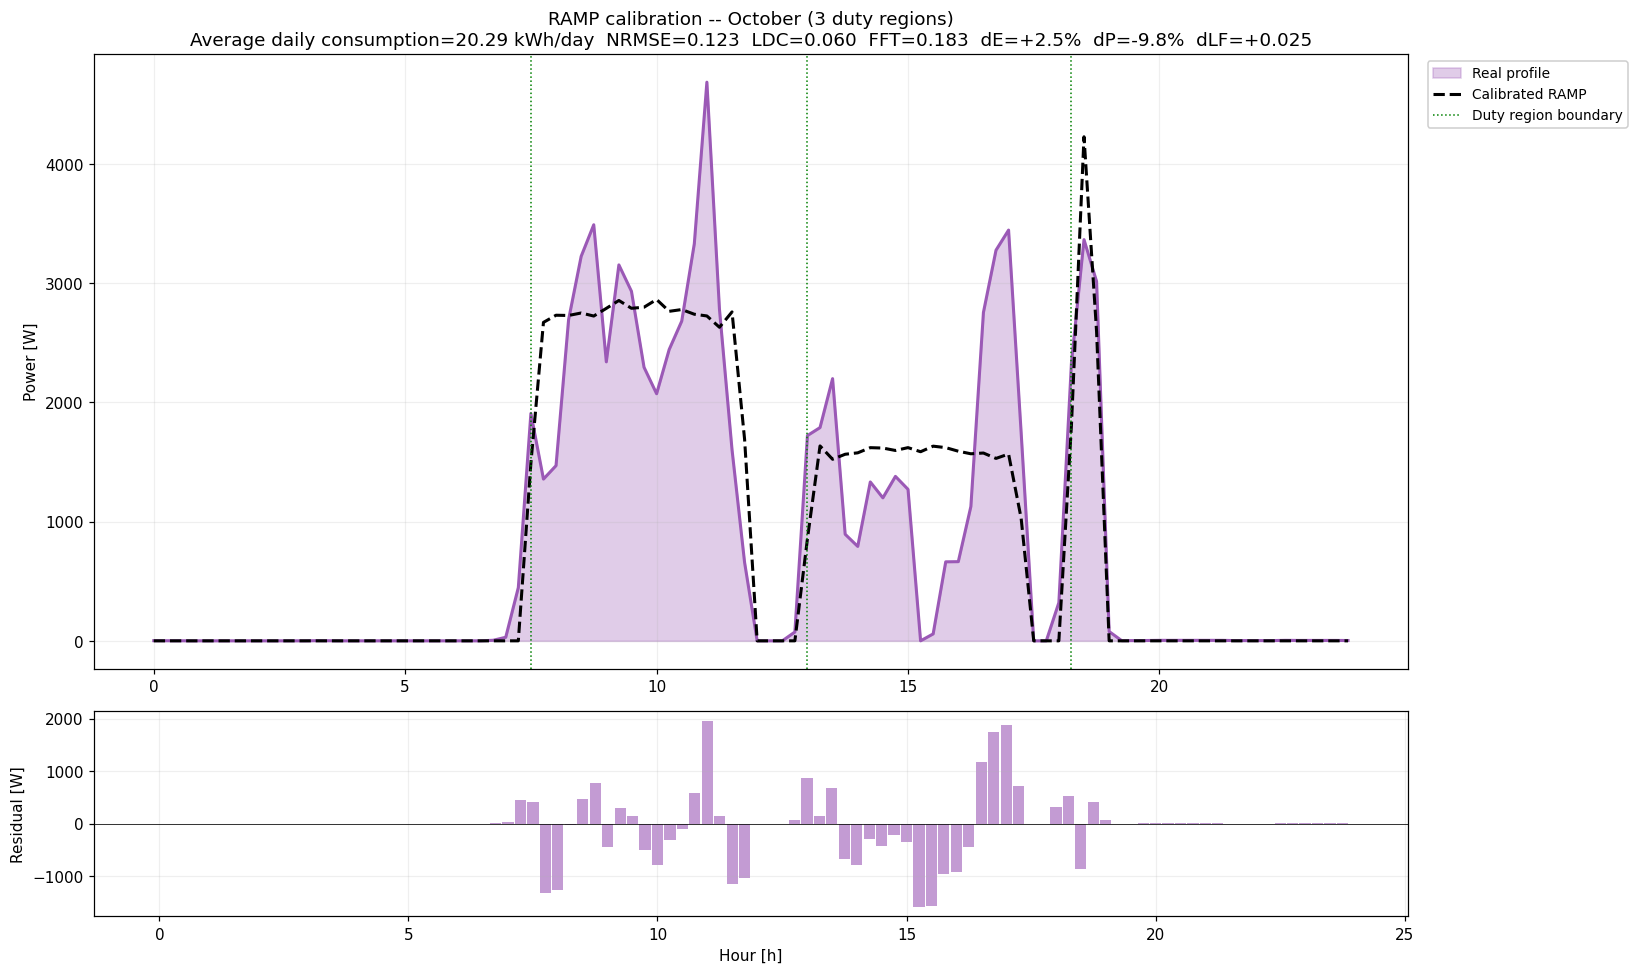

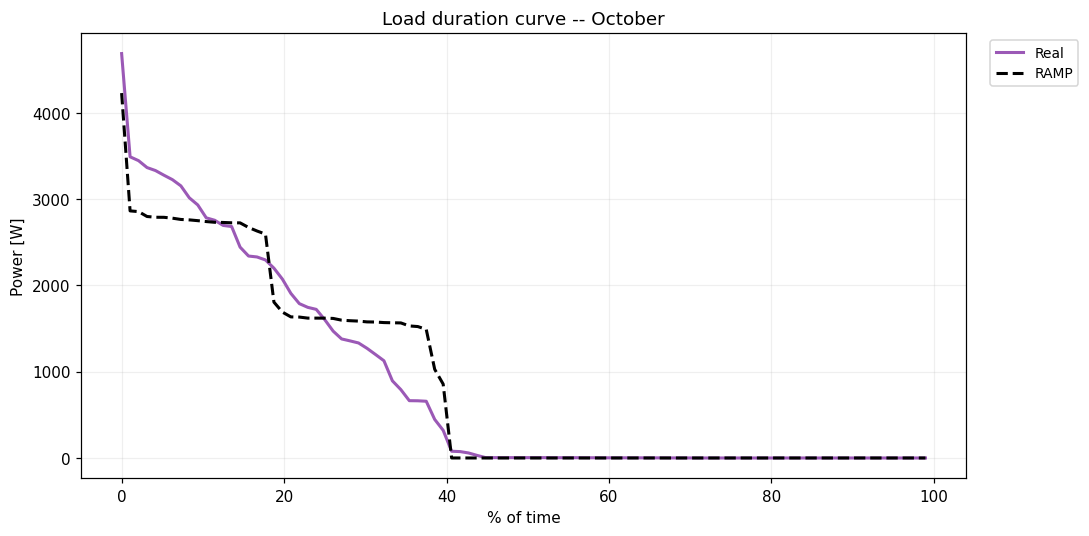

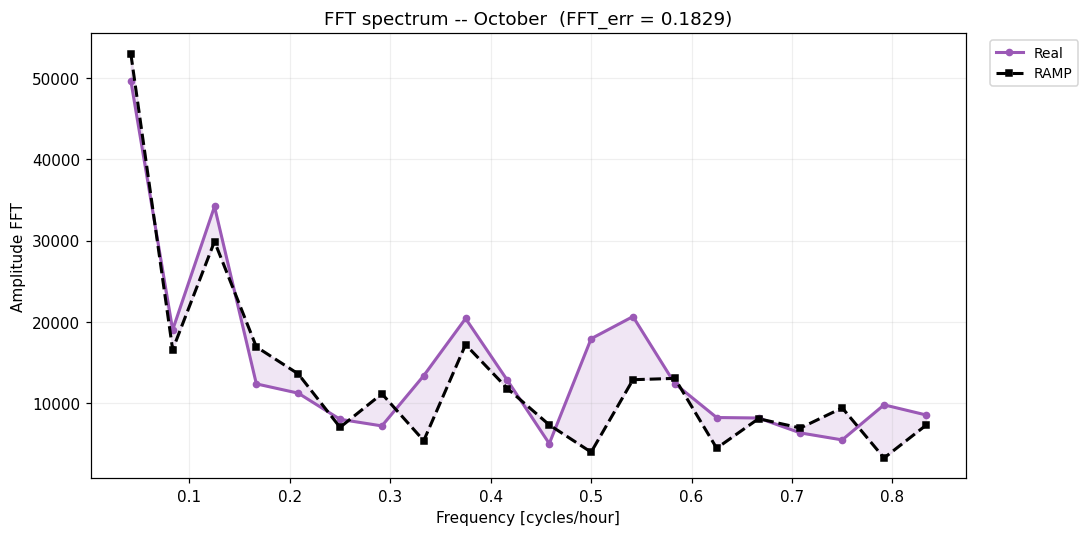

,season,n_pass,NRMSE,LDC_err,FFT_err,err_E_pct,err_P_pct,err_LF
3,October,4,0.123,0.06,0.183,2.533,-9.771,0.025


In [10]:
season = "October"
val = pd.read_csv(RESULTS / "validation_metrics.csv")
row = val[val["season"] == season]
if row.empty:
    print("No calibration for this season (not enough measured days).")
else:
    show(f"40_calib_October.png", f"41_ldc_October.png", f"42_fft_October.png")
    wanted = ["season", "n_pass", "NRMSE", "LDC_err", "FFT_err",
              "err_E_pct", "err_P_pct", "err_LF"]
    cols = [c for c in wanted if c in row.columns]
    display(row[cols].round(3))

## Calibrated RAMP parameters

,season,method_arm,p1_W,p2_W,n_regions,cycle_len_min,func_time_min,func_cycle_min,thermal_p_var,tfrv,...,region1_t_on_min,region1_t_off_min,region2_window,region2_duty,region2_t_on_min,region2_t_off_min,region3_window,region3_duty,region3_t_on_min,region3_t_off_min
0,Dry season,screened,7385.0,0.0,2,52,855,52,0.1,0.940,...,15,37,825-1320,0.244,13,39,NaN,NaN,NaN,NaN
1,May,screened,6395.6,0.0,3,42,840,42,0.1,0.000,...,16,26,855-1080,0.197,8,34,1080-1275,0.138,6.0,36.0
2,Rainy season,screened,6730.2,0.0,3,30,870,30,0.1,0.738,...,9,21,855-1260,0.484,15,15,1260-1320,0.136,4.0,26.0
3,October,classic,5853.6,0.0,3,22,585,22,0.1,0.675,...,12,10,780-1050,0.296,7,15,1095-1140,0.824,18.0,4.0


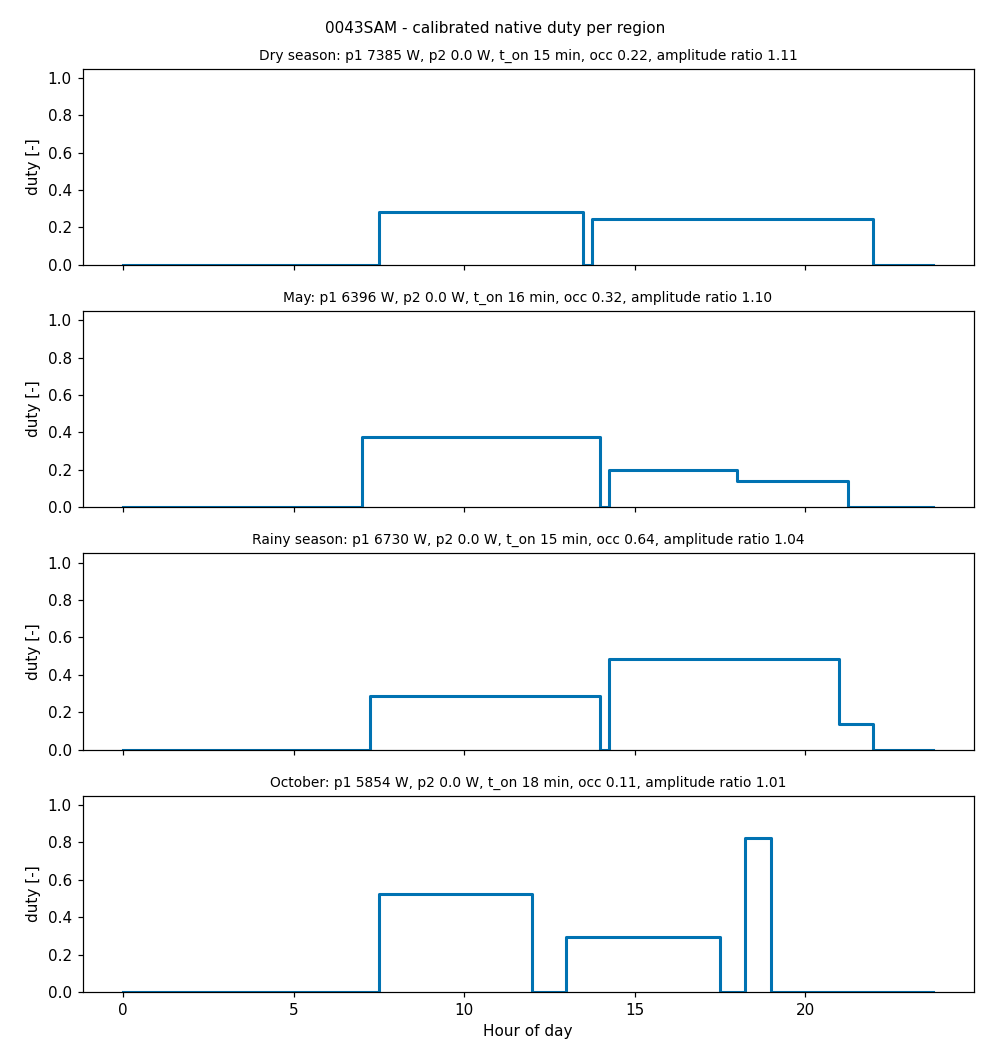

In [11]:
params = pd.read_csv(RESULTS / "appliance_parameters.csv")
display(params.round(3))
show("50_param_summary.png")